# Домашнее задание 11. WGAN


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from torch.autograd import Variable, grad
import time

# Настройки
class Config:
    batch_size = 64
    num_epochs = 20      # Количество эпох для хорошего результата
    noise_size = 100     # Размер вектора шума
    num_classes = 10     # FashionMNIST: 10 классов
    lambda_gp = 10.0     # Коэффициент штрафа градиента (для задания 2)
    n_critic = 5         # Обучаем критик 5 раз на 1 шаг генератора
    lr = 0.0001          # Learning rate

config = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
# Подготовка данных
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,)) # Важно для WGAN (диапазон -1...1)
])

train_dataset = torchvision.datasets.FashionMNIST("fashion_mnist", train=True, transform=transform, download=True)
dataloader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 213kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.57MB/s]


#### 1. Реализация  Wasserstein GAN
Заменяем Discriminator на Critic без сигмоиды на последнем слое.

#### 2. Условная генерация
В оба класса добавляем слоq nn.Embedding. Объединяем входной вектор с вектором, представляющим метку класса.

In [4]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(config.num_classes, config.num_classes)

        # Вход: Шум + Вектор метки
        self.model = nn.Sequential(
            nn.Linear(config.noise_size + config.num_classes, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        c = self.label_emb(labels)
        x = torch.cat([noise, c], 1)
        return self.model(x)

In [5]:
class Critic(nn.Module):
    def __init__(self):
        super(Critic, self).__init__()
        self.label_emb = nn.Embedding(config.num_classes, config.num_classes)

        # Вход: Картинка (flatten) + Вектор метки
        self.model = nn.Sequential(
            nn.Linear(28*28 + config.num_classes, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, img, labels):
        x = img.view(img.size(0), -1)
        c = self.label_emb(labels)
        x = torch.cat([x, c], 1) # Условная проверка: объединяем картинку и метку
        return self.model(x)

# Инициализация
generator = Generator().to(device)
critic = Critic().to(device)
optim_G = optim.Adam(generator.parameters(), lr=config.lr, betas=(0.5, 0.9))
optim_D = optim.Adam(critic.parameters(), lr=config.lr, betas=(0.5, 0.9))

---
#### 3. Gradient Penalty (WGAN-GP)

Вместо Weight Clipping (обрезки весов), добавляем Gradient Penalty.

Clipping заставляет веса скапливаться на границах диапазона, что ухудшает способность сети обучаться. GP мягко штрафует сеть, если градиенты становятся слишком резкими

In [6]:
def calculate_gradient_penalty(critic, real_data, fake_data, labels):
    batch_size = real_data.size(0)
    alpha = torch.rand(batch_size, 1).to(device)
    alpha = alpha.expand_as(real_data)

    # Интерполяция между реальными и фейковыми данными
    interpolates = (alpha * real_data + ((1 - alpha) * fake_data)).requires_grad_(True)

    # Оценка критика интерполированных данных
    disc_interpolates = critic(interpolates, labels)

    # Считаем градиенты
    gradients = grad(
        outputs=disc_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones(disc_interpolates.size()).to(device),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    # Штраф: насколько норма градиента отклоняется от 1
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * config.lambda_gp
    return gradient_penalty

---
#### 4. Обучение:
1)  Используется Wasserstein Loss: mean(fake) - mean(real).
2)  Применяется Gradient Penalty.
3)  Генератор получает случайные метки, чтобы учиться генерировать разные классы.

Начинаем обучение...


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [1/20] completed.
Epoch [2/20] completed.
Epoch [3/20] completed.
Epoch [4/20] completed.
Epoch [5/20] completed.


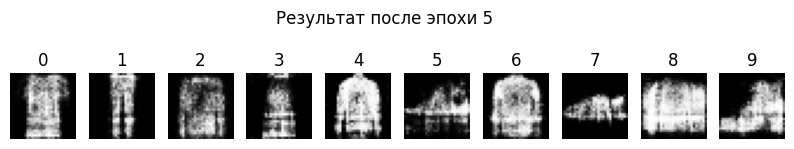

Epoch [6/20] completed.
Epoch [7/20] completed.
Epoch [8/20] completed.
Epoch [9/20] completed.
Epoch [10/20] completed.


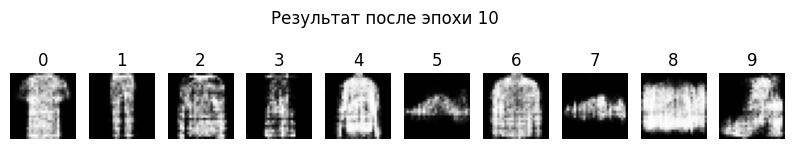

Epoch [11/20] completed.
Epoch [12/20] completed.
Epoch [13/20] completed.
Epoch [14/20] completed.
Epoch [15/20] completed.


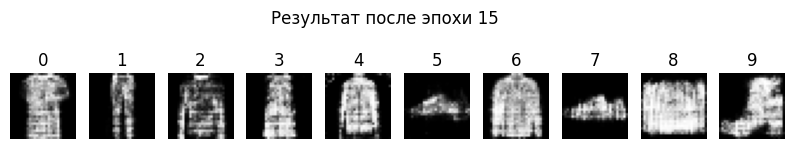

Epoch [16/20] completed.
Epoch [17/20] completed.
Epoch [18/20] completed.
Epoch [19/20] completed.
Epoch [20/20] completed.


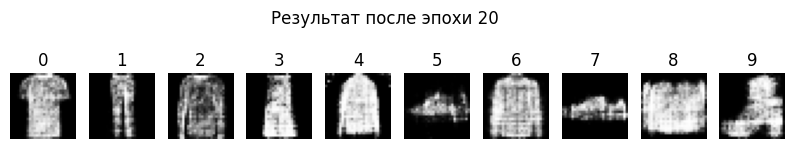

In [7]:
# Фиксированный шум и метки для визуализации (чтобы видеть прогресс на одних и тех же примерах)
fixed_noise = torch.randn(10, config.noise_size).to(device)
fixed_labels = torch.arange(10).long().to(device) # Классы от 0 до 9

losses_g = []
losses_d = []

print("Начинаем обучение...")

for epoch in range(config.num_epochs):
    for i, (imgs, labels) in enumerate(dataloader):

        # Обучение Критика
        # WGAN требует несколько шагов критика на один шаг генератора
        real_imgs = imgs.view(imgs.size(0), -1).to(device)
        labels = labels.to(device)
        batch_size = real_imgs.size(0)

        optim_D.zero_grad()

        # Генерируем фейк
        z = torch.randn(batch_size, config.noise_size).to(device)
        fake_imgs = generator(z, labels).detach()

        # Лосс критика: -(Real - Fake) + GradientPenalty
        loss_D = -torch.mean(critic(real_imgs, labels)) + torch.mean(critic(fake_imgs, labels))
        gp = calculate_gradient_penalty(critic, real_imgs, fake_imgs, labels)

        d_loss = loss_D + gp
        d_loss.backward()
        optim_D.step()

        # Обучение Генератора
        if i % config.n_critic == 0:
            optim_G.zero_grad()

            gen_z = torch.randn(batch_size, config.noise_size).to(device)
            gen_imgs = generator(gen_z, labels)

            g_loss = -torch.mean(critic(gen_imgs, labels))
            g_loss.backward()
            optim_G.step()

            losses_g.append(g_loss.item())
            losses_d.append(d_loss.item())

    print(f"Epoch [{epoch+1}/{config.num_epochs}] completed.")

    # Визуализация каждые 5 эпох
    if (epoch+1) % 5 == 0:
        generator.eval()
        with torch.no_grad():
            fake = generator(fixed_noise, fixed_labels).cpu().view(10, 28, 28)

            # Денормализация для красоты (без нее картинки получались с полосами)
            fake = (fake + 1) / 2

            plt.figure(figsize=(10, 2))
            plt.suptitle(f"Результат после эпохи {epoch+1}")
            for k in range(10):
                plt.subplot(1, 10, k+1)
                plt.imshow(fake[k], cmap='gray')
                plt.axis('off')
                plt.title(f"{k}")
            plt.show()
        generator.train()

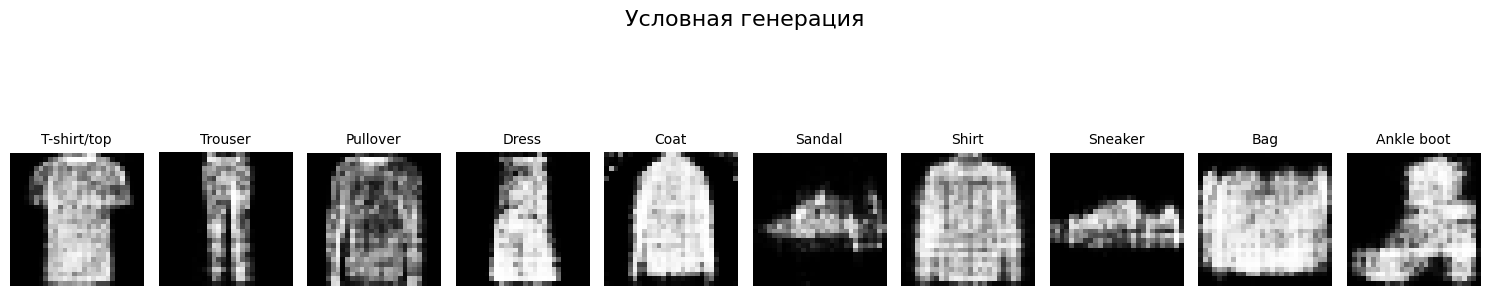

In [9]:
# Финальная визуализация с названиями классов

# Список классов FashionMNIST в правильном порядке
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

generator.eval()
with torch.no_grad():
    # Генерируем картинки (используем тот же фиксированный шум)
    fake = generator(fixed_noise, fixed_labels).cpu().view(10, 28, 28)
    fake = (fake + 1) / 2

    plt.figure(figsize=(15, 4))
    plt.suptitle("Условная генерация", fontsize=16)

    for i in range(10):
        plt.subplot(1, 10, i+1)
        plt.imshow(fake[i], cmap='gray')
        plt.axis('off')
        plt.title(classes[i], fontsize=10)

    plt.tight_layout()
    plt.show()

### 5. Анализ результатов

1.  Начало (1-5 эпохи): Изображения могут быть размытыми, но мы уже видим очертания одежды. Это работает лучше, чем обычный GAN, который мог бы выдать просто шум.
2.  Середина (10 эпох): Формы становятся четче благодаря Gradient Penalty, который стабилизирует обучение.
3.  Финал (20 эпох): Мы четко различаем классы. Благодаря Conditional части, цифра 0 генерирует футболку, 1 - штаны, 9 - ботинок и т.д. Если бы мы не использовали условную генерацию, классы были бы перемешаны.